# Business understanding

Microsoft sees all the big companies creating original video content and they want to get in on the fun. They have decided to create a new movie studio, but they don’t know anything about creating movies. You are charged with exploring what types of films are currently doing the best at the box office. You must then translate those findings into actionable insights that the head of Microsoft's new movie studio can use to help decide what type of films to create.

# Problem Statement

Microsoft lacks industry knowledge on what types of films perform well at the box office

# Main Goal

Microsoft wants to create successful and high-grossing films

# Specifying the Objectives

This Analysis aims to answer the following questions to advise Microsoft on the best types of films to create for their new movie studio:

1.  **Identify the most financially successful movie genres:** Which genres generate the highest gross revenue and profit?
2.  **Analyze the impact of ratings/votes on financial success:** How do average ratings and the number of votes relate to a movie's gross revenue and profitability?
3.  **Examine the performance of existing studios:** Which studios are producing successful films, and what insights can be gained from their financial performance?
4.  **Explore trends in movie performance:** Are there observable trends in movie success metrics or genre popularity over the years covered by the data?

# Defining the Metric for Success

Creating visualizations that can successfully inform the head of Microsoft's new movie studio on what type of films to create.

# Recording the Experimental Design

1. Business Understanding
2. Problem statement
3. Main goal
4. Specifying the objectives
5. Defining metric for success
6. Data preparation
7. Data cleaning
8. Feature engineering
9. EDA
10. Summary and Conclusion
11. Follow up questions

# Data Preparation

### Importing our Libraries

In [2]:
# Let us first import all the libraries we will need for our analysis

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline

# let us set the warnings that may appear in our analysis off

import warnings
warnings.filterwarnings('ignore')

### Loading and Previewing our Datasets

In [3]:
# Loading the Movie Gross Dataset from the source i.e. csv
gross = pd.read_csv('/content/bom.movie_gross.csv.gz')
gross.head()

,title,studio,domestic_gross,foreign_gross,year
0,Toy Story 3,BV,415000000.0,652000000,2010
1,Alice in Wonderland (2010),BV,334200000.0,691300000,2010
2,Harry Potter and the Deathly Hallows Part 1,WB,296000000.0,664300000,2010
3,Inception,WB,292600000.0,535700000,2010
4,Shrek Forever After,P/DW,238700000.0,513900000,2010


In [4]:
# Loading the Title Basics Dataset from the source i.e. csv
basics = pd.read_csv('/content/imdb.title.basics.csv.gz')
basics.head()

,tconst,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [5]:
# Loading the Title Ratings Dataset from the source i.e. csv
ratings = pd.read_csv('/content/imdb.title.ratings.csv.gz')
ratings.head()

,tconst,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21


## Checking the Data

In [6]:
# Determining the no. of records in our dataset
#
print('This dataset has ' + str(gross.shape[0]) + ' rows, and ' + str(gross.shape[1]) + ' columns')
print('This dataset has ' + str(basics.shape[0]) + ' rows, and ' + str(basics.shape[1]) + ' columns')
print('This dataset has ' + str(ratings.shape[0]) + ' rows, and ' + str(ratings.shape[1]) + ' columns')

This dataset has 3387 rows, and 5 columns
This dataset has 146144 rows, and 6 columns
This dataset has 73856 rows, and 3 columns




* The code is used to check the shape and presentation of the data




In [7]:
# Checking whether each column has an appropriate datatype

'''\n is an escape sequence that represents a newline character.
 it tells the program to move to the beginning of the next line before
 continuing to print'''

print("Data types for gross:")
print(gross.dtypes)
print("\nData types for df_title_basics:")
print(basics.dtypes)
print("\nData types for df_title_ratings:")
print(ratings.dtypes)

Data types for gross:
title              object
studio             object
domestic_gross    float64
foreign_gross      object
year                int64
dtype: object

Data types for df_title_basics:
tconst              object
primary_title       object
original_title      object
start_year           int64
runtime_minutes    float64
genres              object
dtype: object

Data types for df_title_ratings:
tconst            object
averagerating    float64
numvotes           int64
dtype: object


In [8]:
# let us see the columns in our dataframe
print("These are the Columns in gross Dataset:")
print(gross.columns)
print("\nThese are the Columns in df_title_basics Dataset:")
print(basics.columns)
print("\nThese are the Columns in df_title_ratings Dataset:")
print(ratings.columns)

These are the Columns in gross Dataset:
Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

These are the Columns in df_title_basics Dataset:
Index(['tconst', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres'],
      dtype='object')

These are the Columns in df_title_ratings Dataset:
Index(['tconst', 'averagerating', 'numvotes'], dtype='object')


In [9]:
# let us see the unique values of all our columns
# so that we can separate out the category and numeric features

for col in list(gross):
    print(col)
    print(gross[col].unique())

for col in list(basics):
    print(col)
    print(basics[col].unique())

for col in list(ratings):
    print(col)
    print(ratings[col].unique())
#

title
['Toy Story 3' 'Alice in Wonderland (2010)'
 'Harry Potter and the Deathly Hallows Part 1' ... 'El Pacto' 'The Swan'
 'An Actor Prepares']
studio
['BV' 'WB' 'P/DW' 'Sum.' 'Par.' 'Uni.' 'Fox' 'Wein.' 'Sony' 'FoxS' 'SGem'
 'WB (NL)' 'LGF' 'MBox' 'CL' 'W/Dim.' 'CBS' 'Focus' 'MGM' 'Over.' 'Mira.'
 'IFC' 'CJ' 'NM' 'SPC' 'ParV' 'Gold.' 'JS' 'RAtt.' 'Magn.' 'Free' '3D'
 'UTV' 'Rela.' 'Zeit.' 'Anch.' 'PDA' 'Lorb.' 'App.' 'Drft.' 'Osci.' 'IW'
 'Rog.' nan 'Eros' 'Relbig.' 'Viv.' 'Hann.' 'Strand' 'NGE' 'Scre.' 'Kino'
 'Abr.' 'CZ' 'ATO' 'First' 'GK' 'FInd.' 'NFC' 'TFC' 'Pala.' 'Imag.' 'NAV'
 'Arth.' 'CLS' 'Mont.' 'Olive' 'CGld' 'FOAK' 'IVP' 'Yash' 'ICir' 'FM'
 'Vita.' 'WOW' 'Truly' 'Indic.' 'FD' 'Vari.' 'TriS' 'ORF' 'IM' 'Elev.'
 'Cohen' 'NeoC' 'Jan.' 'MNE' 'Trib.' 'Rocket' 'OMNI/FSR' 'KKM' 'Argo.'
 'SMod' 'Libre' 'FRun' 'WHE' 'P4' 'KC' 'SD' 'AM' 'MPFT' 'Icar.' 'AGF'
 'A23' 'Da.' 'NYer' 'Rialto' 'DF' 'KL' 'ALP' 'LG/S' 'WGUSA' 'MPI' 'RTWC'
 'FIP' 'RF' 'ArcEnt' 'PalUni' 'EpicPics' 'EOne' 'LD' 



*  We are checking the uniques values on these datasets so that we can be able to identify which variables can be grouped in order to create visual charts like bar charts and pie charts
* Additionally, we want to identify if there are any inconsistencies and typos in the dataset. From the output we can see that the year column in the title basics dataset has a typo of 2115 as a year




# Data Cleaning

In [10]:
# let us make a copy of our dataset to clean and do modelling on
# we are making copies to clean and analyse so that we can keep the original raw data unaltered
# in case we need to go back to this original data at any point in our analysis
gross_copy = gross.copy(deep = True)
basics_copy = basics.copy(deep = True)
ratings_copy = ratings.copy(deep = True)

In [11]:
# For consistency, let us make the column names uniform
# Let us do this by changing all column names to lower case
#
gross_copy.columns = gross_copy.columns.str.lower()
basics_copy.columns = basics_copy.columns.str.lower()
ratings_copy.columns = ratings_copy.columns.str.lower()
# Previewing the columns to confirm whether the changes have taken effect
#
# let us see the columns in our dataframe
print("These are the Columns in gross Dataset:")
print(gross_copy.columns)
print("\nThese are the Columns in df_title_basics Dataset:")
print(basics_copy.columns)
print("\nThese are the Columns in df_title_ratings Dataset:")
print(ratings_copy.columns)

These are the Columns in gross Dataset:
Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

These are the Columns in df_title_basics Dataset:
Index(['tconst', 'primary_title', 'original_title', 'start_year',
       'runtime_minutes', 'genres'],
      dtype='object')

These are the Columns in df_title_ratings Dataset:
Index(['tconst', 'averagerating', 'numvotes'], dtype='object')


In [12]:
# we had identified the row with the incorrect year '2115' in the 'start_year' column
print("Rows with start_year 2115:")
display(basics_copy[basics_copy['start_year'] == 2115])

# Assuming the typo is a simple mistake and it should be 2015, let us correct it.
# If there were multiple such typos or no clear correction,
# we might consider dropping or investigating further.
basics_copy['start_year'] = basics_copy['start_year'].replace(2115, 2015)

# Let us verify that we have corrected the typo by printing any rows with year 2115
print("\nRows with start_year 2115 after correction:")
display(basics_copy[basics_copy['start_year'] == 2115])

print("\nUnique values in start_year after correction:")
print(basics_copy['start_year'].unique())

# from the output, we can see that we have corrected the typo

Rows with start_year 2115:


,tconst,primary_title,original_title,start_year,runtime_minutes,genres
89506,tt5174640,100 Years,100 Years,2115,NaN,Drama



Rows with start_year 2115 after correction:


,tconst,primary_title,original_title,start_year,runtime_minutes,genres



Unique values in start_year after correction:
[2013 2019 2018 2017 2012 2010 2011 2015 2021 2016 2014 2020 2022 2023
 2024 2026 2025 2027]


In [13]:
# Let us check for any duplicates in our datasets
print(gross_copy.duplicated().sum())
print(basics_copy.duplicated().sum())
print(ratings_copy.duplicated().sum())

0
0
0


In [14]:
# now that we have identified that there are no duplictaes
# let us check for missing values in our dataframe
print("These are the null values in gross Dataset:")
print(gross_copy.isnull().sum())
print("\nThese are the null values in df_title_basics Dataset:")
print(basics_copy.isnull().sum())
print("\nThese are the null values in df_title_ratings Dataset:")
print(ratings_copy.isnull().sum())


These are the null values in gross Dataset:
title                0
studio               5
domestic_gross      28
foreign_gross     1350
year                 0
dtype: int64

These are the null values in df_title_basics Dataset:
tconst                 0
primary_title          1
original_title        22
start_year             0
runtime_minutes    31739
genres              5408
dtype: int64

These are the null values in df_title_ratings Dataset:
tconst           0
averagerating    0
numvotes         0
dtype: int64


In [15]:
# Let us clean the datasets based on their data types
# We can see that there are missing values in our gross and basics datasets
# let us clean the 'foreign_gross' column in gross_copy
# let us remove commas and convert these columns to numeric
gross_copy['foreign_gross'] = gross_copy['foreign_gross'].str.replace(',', '', regex=False)
gross_copy['foreign_gross'] = pd.to_numeric(gross_copy['foreign_gross'])

In [16]:
# in the primary title column we only have one missing value
# let us drop thisrow
basics_copy.dropna(subset=['primary_title'], inplace=True)

In [17]:
# for the studio, title and genre column we will fill the null values
# for completeness of the data we will fill these with a placeholder labelled 'Unknown'
gross_copy['studio'].fillna('Unknown', inplace=True)
basics_copy['original_title'].fillna('Unknown', inplace=True)
basics_copy['genres'].fillna('Unknown', inplace=True)

In [18]:
# Let us also fill in the gross values and runtime minutes
# For numerical columns, let us fill these values with the median
# we chose to fill null values with the median because teh median value is less
# affected by outliers compared to the mean
# for this data, financials like gross revenue can heavily be affected by outliers
# because there might be extremely high grossing films or low grossing films
# with this in mind, the mean would be highly affected by these extremely values
# which would lead to an inaccurate represenation of mean value
gross_copy['domestic_gross'].fillna(gross_copy['domestic_gross'].median(), inplace=True)
gross_copy['foreign_gross'].fillna(gross_copy['foreign_gross'].median(), inplace=True)
basics_copy['runtime_minutes'].fillna(basics_copy['runtime_minutes'].median(), inplace=True)

In [19]:
# now that we have cleaned the data
# let us verify that missing values have been handled
print("Missing values after handling in gross_copy:")
print(gross_copy.isnull().sum())
print("\nMissing values after handling in basics_copy:")
print(basics_copy.isnull().sum())
print("\nMissing values after handling in ratings_copy:")
print(ratings_copy.isnull().sum())

Missing values after handling in gross_copy:
title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
dtype: int64

Missing values after handling in basics_copy:
tconst             0
primary_title      0
original_title     0
start_year         0
runtime_minutes    0
genres             0
dtype: int64

Missing values after handling in ratings_copy:
tconst           0
averagerating    0
numvotes         0
dtype: int64


The data is now clean, let us go to feature engineering

# Feature Engineering

In [20]:
# We have loaded 3 datasets into our notebook
# we however, need to merge these datasets in order to perform analysis on one dataset
# let us merge ratings and title basics first as they have a similar column "tconst"
merged_basics_ratings = pd.merge(basics_copy, ratings_copy, on='tconst', how='inner')
merged_basics_ratings.head()

#rename the title column in gross data to primary_title so we can merge this dataset too
gross_copy.rename(columns={'title': 'primary_title'}, inplace=True)

#merge basics_ratings to gross dataframe
merged = pd.merge(gross_copy, merged_basics_ratings, on='primary_title', how='inner')

print("Merged DataFrame with Gross Information:")
display(merged.head())


Merged DataFrame with Gross Information:


,primary_title,studio,domestic_gross,foreign_gross,year,tconst,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,Toy Story 3,BV,415000000.0,652000000.0,2010,tt0435761,Toy Story 3,2010,103.0,"Adventure,Animation,Comedy",8.3,682218
1,Inception,WB,292600000.0,535700000.0,2010,tt1375666,Inception,2010,148.0,"Action,Adventure,Sci-Fi",8.8,1841066
2,Shrek Forever After,P/DW,238700000.0,513900000.0,2010,tt0892791,Shrek Forever After,2010,93.0,"Adventure,Animation,Comedy",6.3,167532
3,The Twilight Saga: Eclipse,Sum.,300500000.0,398000000.0,2010,tt1325004,The Twilight Saga: Eclipse,2010,124.0,"Adventure,Drama,Fantasy",5.0,211733
4,Iron Man 2,Par.,312400000.0,311500000.0,2010,tt1228705,Iron Man 2,2010,124.0,"Action,Adventure,Sci-Fi",7.0,657690


Let us just do a check on the merged dataset

In [21]:
# Determining the no. of records in our merged dataset
print('This dataset has ' + str(merged.shape[0]) + ' rows, and ' + str(merged.shape[1]) + ' columns')

This dataset has 3027 rows, and 12 columns


In [22]:
#check for duplicates in the merged dataframe
merged.duplicated().sum()

np.int64(0)

In [23]:
# let us check for missng values in merged dataframe
print("These are the null values in gross Dataset:")
print(merged.isnull().sum())

These are the null values in gross Dataset:
primary_title      0
studio             0
domestic_gross     0
foreign_gross      0
year               0
tconst             0
original_title     0
start_year         0
runtime_minutes    0
genres             0
averagerating      0
numvotes           0
dtype: int64


our merged datsets have no duplicates and no null values

In [24]:
# our genres column is inconsistent as movies have more than one genre
# we need to split the string into a list of individual genres for each movie
# after splitting the string, we then use the explode function to create
# a new row for each genre, duplicating the other information for that movie
merged["genres"] = merged["genres"].str.split(",")
merged = merged.explode("genres")
merged.head()

,primary_title,studio,domestic_gross,foreign_gross,year,tconst,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,Toy Story 3,BV,415000000.0,652000000.0,2010,tt0435761,Toy Story 3,2010,103.0,Adventure,8.3,682218
0,Toy Story 3,BV,415000000.0,652000000.0,2010,tt0435761,Toy Story 3,2010,103.0,Animation,8.3,682218
0,Toy Story 3,BV,415000000.0,652000000.0,2010,tt0435761,Toy Story 3,2010,103.0,Comedy,8.3,682218
1,Inception,WB,292600000.0,535700000.0,2010,tt1375666,Inception,2010,148.0,Action,8.8,1841066
1,Inception,WB,292600000.0,535700000.0,2010,tt1375666,Inception,2010,148.0,Adventure,8.8,1841066


In [25]:
# Let us relocate the tconst column to be the first

# pop() removes the column in place and returns the removed column.
tconst_column = merged.pop('tconst')
# insert the 'tconst' column back into the merged DataFrame
merged.insert(0, 'tconst', tconst_column)

# Display the first few rows to confirm the change
print("DataFrame with 'tconst' column moved to the front:")
display(merged.head())

DataFrame with 'tconst' column moved to the front:


,tconst,primary_title,studio,domestic_gross,foreign_gross,year,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
0,tt0435761,Toy Story 3,BV,415000000.0,652000000.0,2010,Toy Story 3,2010,103.0,Adventure,8.3,682218
0,tt0435761,Toy Story 3,BV,415000000.0,652000000.0,2010,Toy Story 3,2010,103.0,Animation,8.3,682218
0,tt0435761,Toy Story 3,BV,415000000.0,652000000.0,2010,Toy Story 3,2010,103.0,Comedy,8.3,682218
1,tt1375666,Inception,WB,292600000.0,535700000.0,2010,Inception,2010,148.0,Action,8.8,1841066
1,tt1375666,Inception,WB,292600000.0,535700000.0,2010,Inception,2010,148.0,Adventure,8.8,1841066


In [26]:
# Let us create a new column in the merged dataset called total_gross
# we will use the total gross column for our analysis
merged['total_gross'] = merged['domestic_gross'] + merged['foreign_gross']

# Display the first few rows to confirm the new column
print("DataFrame with 'total_gross' column added:")
display(merged.head())

DataFrame with 'total_gross' column added:


,tconst,primary_title,studio,domestic_gross,foreign_gross,year,original_title,start_year,runtime_minutes,genres,averagerating,numvotes,total_gross
0,tt0435761,Toy Story 3,BV,415000000.0,652000000.0,2010,Toy Story 3,2010,103.0,Adventure,8.3,682218,1.067000e+09
0,tt0435761,Toy Story 3,BV,415000000.0,652000000.0,2010,Toy Story 3,2010,103.0,Animation,8.3,682218,1.067000e+09
0,tt0435761,Toy Story 3,BV,415000000.0,652000000.0,2010,Toy Story 3,2010,103.0,Comedy,8.3,682218,1.067000e+09
1,tt1375666,Inception,WB,292600000.0,535700000.0,2010,Inception,2010,148.0,Action,8.8,1841066,8.283000e+08
1,tt1375666,Inception,WB,292600000.0,535700000.0,2010,Inception,2010,148.0,Adventure,8.8,1841066,8.283000e+08


Now that we have merged the dataset and added some new features(total gross, separated the genres column) into our dataset, let us move on to the Analysis so we can derive useful insights to advise microsoft

# EDA

### Identify the most financially successful movie genres

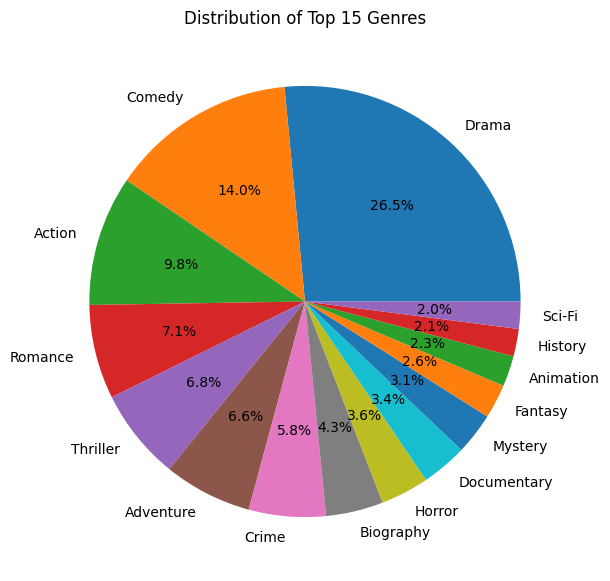

In [27]:
# Let us first identify thewhich movie genres are most prevalent in our merged dataset

# Calculate the frequency of each genre
genre_counts = merged['genres'].value_counts()

# Plot the pie chart - limiting to top N genres for better visualization
# limit the pie chart to only show the top 15 most frequent genres, making the chart more readable
top_n_genres = 15
genre_counts.head(top_n_genres).plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7))
plt.title(f'Distribution of Top {top_n_genres} Genres')
plt.ylabel('') # Remove the default 'genres' label on the y-axis
plt.show()

Based on this piechart, we can see that drama, comedy and action are the most prevalent genres in this dataset.
However, to make these findings actionable for Microsoft,
let us investigate if the prevalence of a genre correlates with its success.

In [28]:
# for us to correlate the genre to its success,
#  we willalculate the median total gross for each genre
genre_gross = merged.groupby('genres')['total_gross'].median().sort_values(ascending=False)

# let us display the median total gross per genre
print("Median Total Gross per Genre:")
display(genre_gross)


Median Total Gross per Genre:


,total_gross
genres,
Adventure,148700000.0
Sci-Fi,137000000.0
Animation,119400000.0
Unknown,101200000.0
Action,53500000.0
Fantasy,45550000.0
Family,45300000.0
Sport,24000000.0
Horror,23300000.0


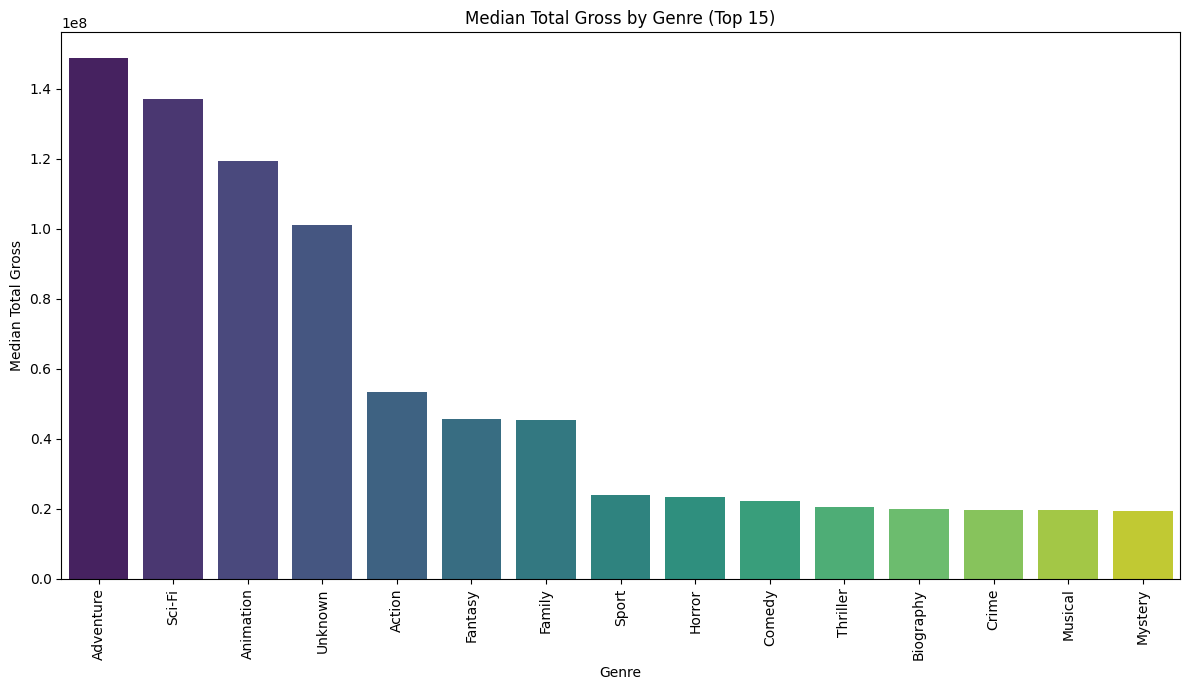

In [29]:
# let us Visualize the info above using a bar plot
plt.figure(figsize=(12, 7))

# Selecting top genres by total gross for visualization
# we will visualize the top 15 genres by total gross
top_genres_by_gross = genre_gross.head(15)
sns.barplot(x=top_genres_by_gross.index, y=top_genres_by_gross.values, palette='viridis')
plt.title('Median Total Gross by Genre (Top 15)')
plt.xlabel('Genre')
plt.ylabel('Median Total Gross')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

From the bar graph above, we can clearly see that the top performing genres are Adventure, Sci-fi and Animations. This suggests that movies in these genres tend to earn significantly more at the box office compared to others in the dataset.

Comparing this to the pie chart earlier, where Drama and Comedy are the most prevalent genres in the dataset, their median total gross is considerably lower than the top-performing genres. This indicates that while many movies are made in these genres, their typical financial return is not as high as that of genres like Adventure or Sci-Fi.

Action movies are also prevalent and show a moderate median total gross, placing them below the top three but still higher than many other genres.

We can also see that the unknown genre has a relatively high median total gross. These were movies that had missing values in the genre column which we filled with unknown, and some of them appear to be successful films.

From these insights drawn from the analysis above, we would advise Microsoft to focus on Adventure, Sci-Fi and Animated Movies to maximize their financial success.

### Analyze the impact of Ratings/Votes on financial success

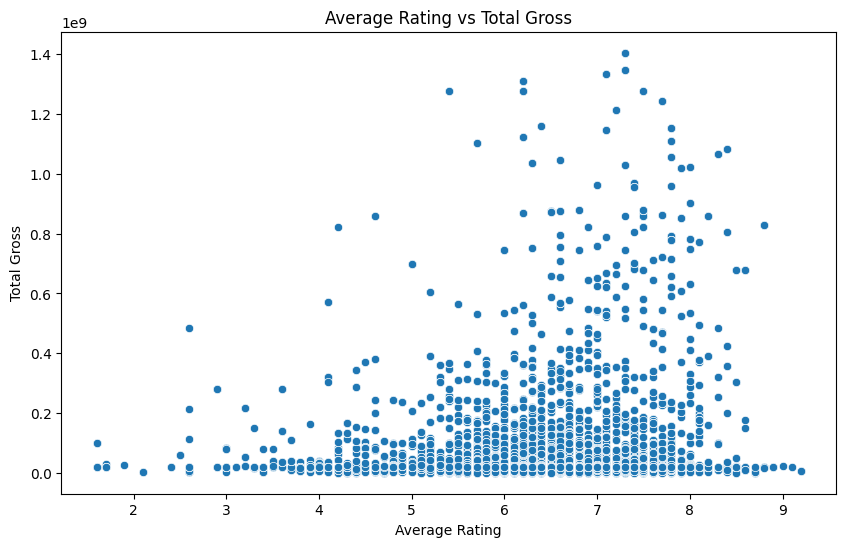

In [30]:
# Relationship between Ratings and Gross Revenue

# Scatter plot of Average Rating vs Total Gross
plt.figure(figsize=(10, 6))
sns.scatterplot(x='averagerating', y='total_gross', data=merged)
plt.title('Average Rating vs Total Gross')
plt.xlabel('Average Rating')
plt.ylabel('Total Gross')
plt.show()

From the above scatter plot, there is a weak positive trend.
There are high grossing movies with high ratings, while there are high grossing movies with average or below average ratings.
Conversely, there are movies with high ratings that did not achieve very high total gross.
This visually confirms that a high average rating does not guarantee high box office success, and many successful movies are not necessarily the most critically acclaimed

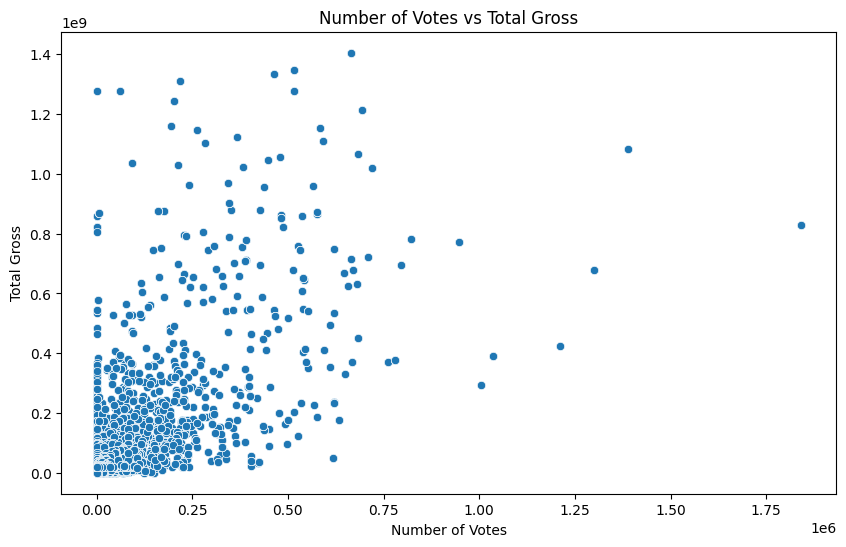

In [31]:
# Scatter plot of Number of Votes vs Total Gross
plt.figure(figsize=(10, 6))
sns.scatterplot(x='numvotes', y='total_gross', data=merged)
plt.title('Number of Votes vs Total Gross')
plt.xlabel('Number of Votes')
plt.ylabel('Total Gross')
plt.show()

The scatter plot above, shows a clearer positive trend than the rating vs. gross plot. As the number of votes increases, the total gross tends to increase.
There is a visible cluster of movies with lower votes and lower gross, and as you move to higher vote counts, the potential for higher total gross generally increases.

This suggests that movies that generate more audience engagement (indicated by a higher number of votes) are more likely to achieve higher box office revenues.

The number of votes appears to be a better indicator of potential financial success than the average rating.

From the above analysis, we can advise microsoft that audience engagement matters more for Revenue.

The number of votes appears to be a better indicator of potential total gross than the average rating. This suggests that focusing on making movies that resonate with a large audience and generate significant buzz (leading to more votes) might be a more reliable strategy for financial success than solely aiming for critical acclaim.

### Examine the performance of existing studios

In [32]:
# Let us now analyse whic studios produce high grossing films

# we will group by studio and calculate median gross revenues
# we are using the median due to skewed data
studio_gross = merged.groupby('studio')[['domestic_gross', 'foreign_gross', 'total_gross']].median().sort_values(by='total_gross', ascending=False)
# the median is used because gross revenue data is often skewed by blockbusters.
# let us display the median gross revenues per studio
print("Median Gross Revenue per Studio:")
display(studio_gross)

Median Gross Revenue per Studio:


,domestic_gross,foreign_gross,total_gross
studio,,,
HC,2700000.0,867600000.0,870300000.0
P/DW,165200000.0,405700000.0,555000000.0
BV,128000000.0,177600000.0,299300000.0
GrtIndia,20200000.0,234000000.0,254200000.0
Fox,68400000.0,101700000.0,177200000.0
...,...,...,...
AGF,15800.0,161000.0,176800.0
FOAK,107000.0,17300.0,124300.0
First,2000.0,53600.0,55600.0


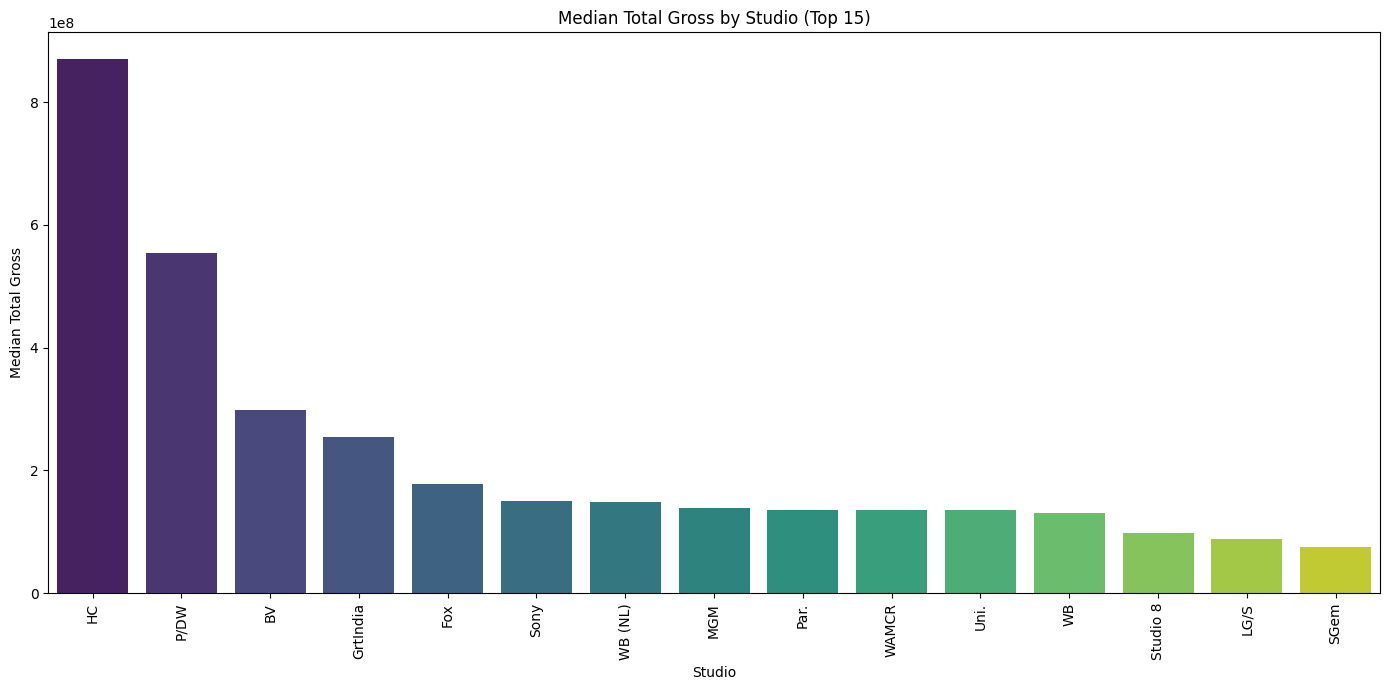

In [33]:
# now let us visualize the above information using a bar plot of top studios
plt.figure(figsize=(14, 7))
top_studios_by_gross = studio_gross.head(15) # Select top 15 studios by median total gross
sns.barplot(x=top_studios_by_gross.index, y=top_studios_by_gross['total_gross'], palette='viridis')
plt.title('Median Total Gross by Studio (Top 15)')
plt.xlabel('Studio')
plt.ylabel('Median Total Gross')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The bar plot clearly highlights the studios with the highest median total gross revenue. These are the studios whose typical movies tend to earn the most globally. Based on the output, studios like HC, P/DW, and BV appear to have the highest median total gross.

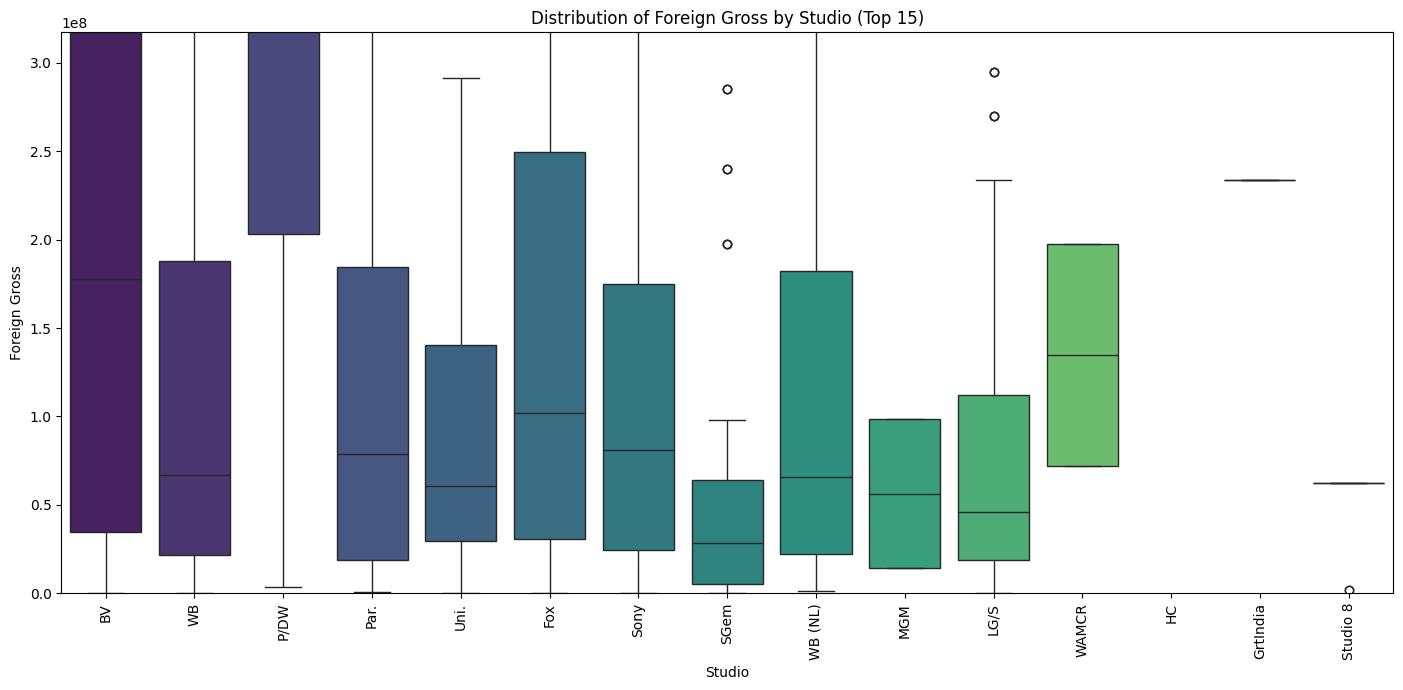

In [34]:
# Let us now plot some boxplots to visualize the distribution of Foreign Gross by
# Studio for top studios using box plot
plt.figure(figsize=(14, 7))
sns.boxplot(x='studio', y='foreign_gross', data=merged[merged['studio'].isin(top_studios_by_gross.index)], palette='viridis')
plt.title('Distribution of Foreign Gross by Studio (Top 15)')
plt.xlabel('Studio')
plt.ylabel('Foreign Gross')
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0, merged['foreign_gross'].quantile(0.95)) # Limit y-axis to see distribution better
plt.show()

Studios with Higher Median Foreign Gross: HC, P/DW, and BV stand out with very high median foreign gross. This suggests their typical movies are particularly successful in international markets.

Studios like BV show relatively tight boxes, indicating more consistent foreign earnings for their films.

Studios like WB, P/DW, Uni., Fox, Sony, WB (NL), MGM, and Par. have wider boxes, signifying greater variability in their foreign gross. They might have some films that perform exceptionally well internationally and others with more moderate foreign earnings

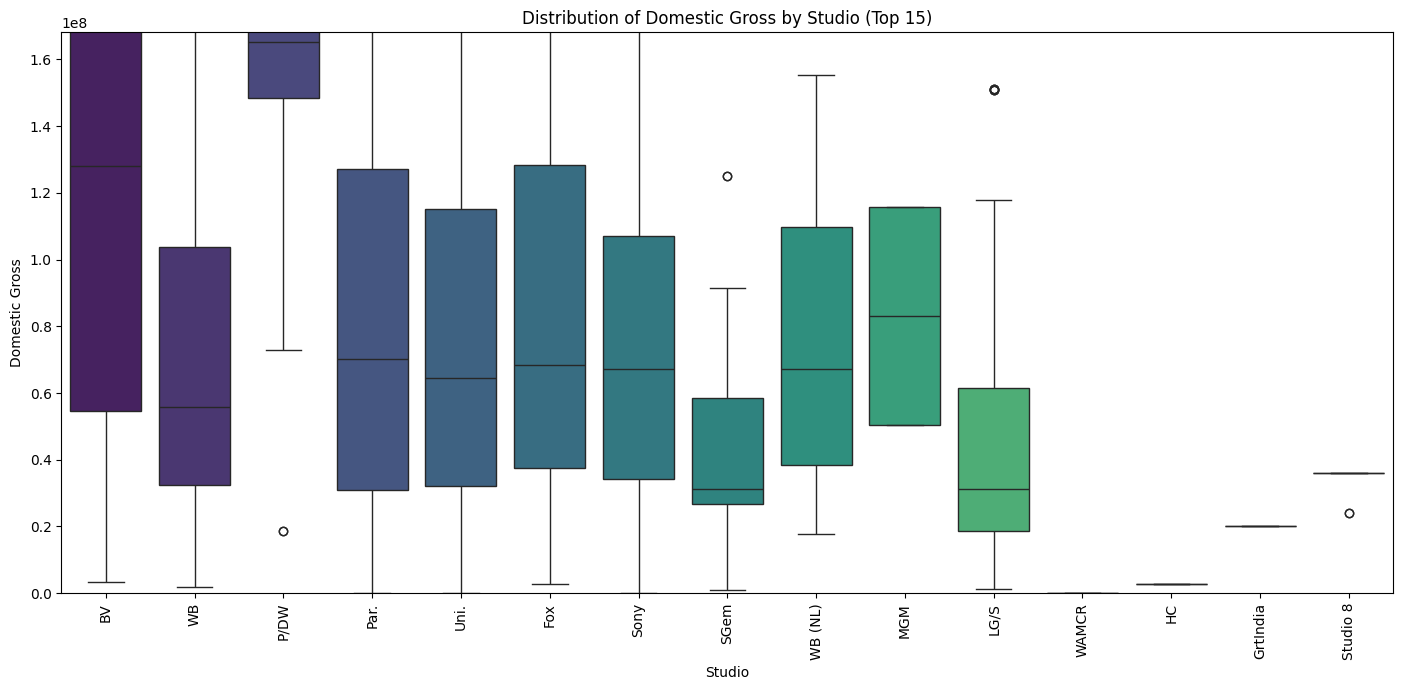

In [35]:
# Let us now plot some boxplots to visualize the distribution of Domestic Gross by Studio for top studios using box plot
plt.figure(figsize=(14, 7))
sns.boxplot(x='studio', y='domestic_gross', data=merged[merged['studio'].isin(top_studios_by_gross.index)], palette='viridis')
plt.title('Distribution of Domestic Gross by Studio (Top 15)')
plt.xlabel('Studio')
plt.ylabel('Domestic Gross')
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0, merged['domestic_gross'].quantile(0.95)) # Limit y-axis to see distribution better
plt.show()

Studios like BV, P/DW, and Fox appear to have relatively high median domestic gross, indicated by the position of the median line within their boxes. This suggests that their typical movies perform well in the domestic market.

Some studios, like BV and WB, show relatively tighter boxes, suggesting that their domestic gross revenues are more consistent across their films.

Other studios, such as Par., Uni., and Sony, have wider boxes, indicating a greater variability in their domestic earnings. They might produce a mix of moderately successful films and some that perform significantly better or worse domestically.

This analysis provides insights into the competitive landscape of movie studios which helps Microsoft understand:
1.   The most financially successful existing studios based on their median gross
2.  The range and variability of earnings for movies produced by these top studios.
3. How certain studios excel in domestic and foreign markets, or in producing
consistent earners versus high-risk/high-reward blockbusters.

This information is useful to Microsoft's strategy regarding potential partnerships, talent acquisition, or the types of films they might aim to produce based on the performance patterns of established studios.

### Explore trends in movie performance

To understand trends in movie performance, we will analyze how metrics like total gross, average rating, and number of votes have changed over the years included in the dataset.

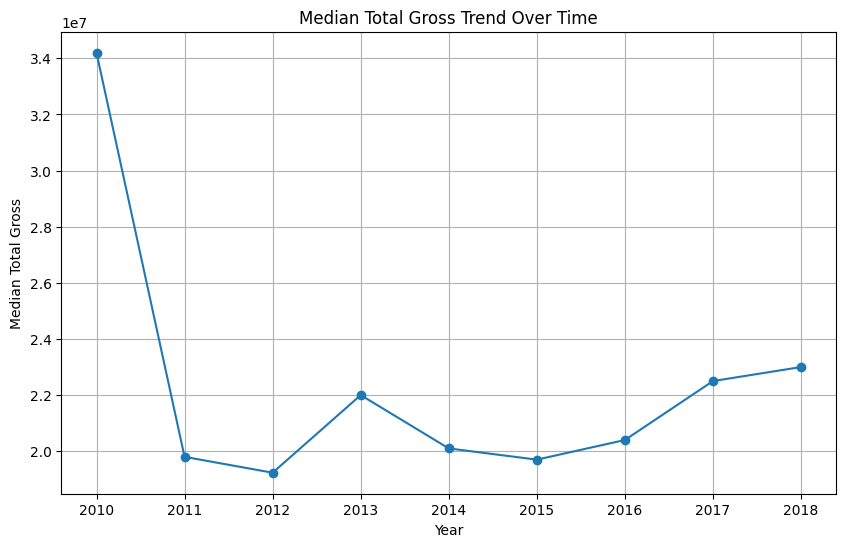

In [36]:
# Analyze trends in Total Gross over time (by year)
yearly_gross_trend = merged.groupby('year')['total_gross'].median()

plt.figure(figsize=(10, 6))
yearly_gross_trend.plot(kind='line', marker='o')
plt.title('Median Total Gross Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Median Total Gross')
plt.grid(True)
plt.show()

From the line graph above, we see that there was significant decline in total gross from 2010-2011, this could be an anomaly based on the specific movies included in the dataset, or it could mean that there was a great market shift for movies between 2010-2011.
However, after 2011, the median total gross appears to fluctuate but generally remains in a similar range, with a slight upward trend from 2016 to 2018.
There isn't a clear, consistent upward trend in median total gross across the entire period (2010-2018). This suggests that while some years might have performed better than others in terms of typical movie revenue, the market's overall median financial performance hasn't drastically increased within this timeframe based on this dataset.

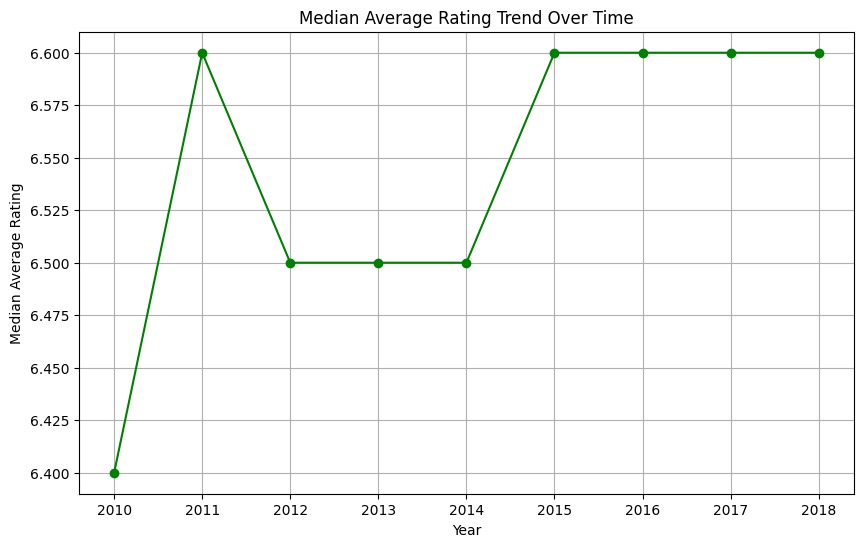

In [37]:
# Analyze trends in Average Rating over time (by year)
yearly_rating_trend = merged.groupby('year')['averagerating'].median()

plt.figure(figsize=(10, 6))
yearly_rating_trend.plot(kind='line', marker='o', color='green')
plt.title('Median Average Rating Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Median Average Rating')
plt.grid(True)
plt.show()

The median average rating starts at 6.4 in 2010 and quickly rises to 6.6 in 2011.
From 2011 onwards, the median average rating remains relatively stable, hovering around 6.5 and 6.6.
There is no strong upward or downward trend in median average rating over the years covered. This indicates that, on average, the critical or audience reception (as reflected in ratings) of movies hasn't changed significantly from 2011 to 2018 within this dataset.

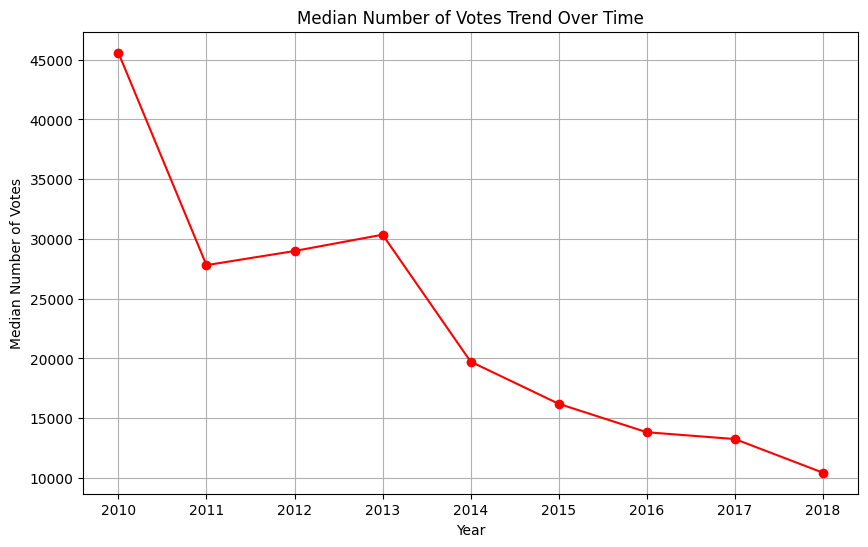

In [38]:
# Analyze trends in Number of Votes over time (by year)
yearly_votes_trend = merged.groupby('year')['numvotes'].median()

plt.figure(figsize=(10, 6))
yearly_votes_trend.plot(kind='line', marker='o', color='red')
plt.title('Median Number of Votes Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Median Number of Votes')
plt.grid(True)
plt.show()

The median number of votes shows a clear downward trend from 2010 to 2018. There's a sharp drop from 2010 to 2011, and then a more gradual but consistent decline in the following years.

This trend suggests that the typical movie in this dataset is receiving fewer audience votes over time. This could indicate a decrease in audience engagement.

The above trend analysis reveals a market with relatively stable typical revenue and ratings but a concerning decline in typical audience engagement as measured by votes. Microsoft needs to focus on strategies to stand out and generate significant buzz to counteract the trend of declining typical engagement.

# Summary and Conclusion

Based on the analysis we have performed above, we can make the below conclusions:

**1. Most Financially Successful Movie Genres:**

*   Adventure, Sci-Fi, and Animation genres demonstrate the highest median total gross revenue among the genres analyzed. While Drama and Comedy are prevalent, their typical financial returns are significantly lower.
*   Based on this, we advise Microsoft to prioritize producing movies in **Adventure, Sci-Fi, and Animation** genres to maximize their potential for high box office returns.

**2. Impact of Ratings and Audience Engagement on Financial Success:**

*   The number of audience votes is a better indicator of potential total gross revenue than the average rating. High ratings alone do not guarantee high box office success, but movies with higher audience engagement (more votes) tend to perform better financially.
*  Based on this, we advise Microsoft to focus on creating movies that generate significant **audience engagement and buzz**. Marketing and distribution strategies should prioritize reaching a wide audience and encouraging interaction.

**3. Performance of Existing Studios:**

*  Studios like HC, P/DW, and BV show high median total gross, indicating strong typical performance. The analysis of domestic and foreign gross distributions reveals that some studios excel in specific markets and have varying levels of consistency and potential for blockbusters.
*   Based on this, Microsoft can study and learn from the strategies of successful studios, particularly those with high median gross and consistent performance in target markets. This could inform decisions about genre focus, production scale, and potential talent acquisition or partnerships. Understanding the variability in earnings can also help Microsoft define its own risk tolerance and production goals (consistent earners vs. high-risk blockbusters).

**4. Trends in Movie Performance:**

*   Median total gross has been relatively stable after an initial dip in 2011. Median average ratings have also remained consistent. However, the median number of audience votes has shown a clear downward trend from 2010 to 2018.
*   The declining trend in audience engagement (votes) is a significant factor. Microsoft needs to develop strategies to counteract this trend and ensure their movies capture audience attention and generate interaction in a competitive market. Simply producing movies may not be enough; focusing on unique concepts, effective marketing, and engaging content will be crucial.


In Conclusion: To enter the movie industry successfully, Microsoft should strategically focus on **high-grossing genres like Adventure, Sci-Fi, and Animation**. While striving for quality (good ratings), they must prioritize **generating strong audience engagement** as this correlates more closely with financial success.
Understanding the landscape of existing successful studios and the **trend of declining typical audience engagement** is vital for developing a competitive strategy that aims to stand out and capture market attention.

## Follow up questions

### a). Did we have the right data?

Yes we had the right data.
The datasets provided key metrics like domestic gross, foreign gross, average rating, and number of votes, which are directly relevant to answering our specific objectives.
Additionallay, we had information on genre, studio, and year of release which allowed us to explore how these attributes relate to general movie performance.

### b). Do we need other data to answer our question?

We would probably need data from more recent years to provide a more current perspective because market trends and audience preference tend to change over time. (our data only covers 2010-2018)